# Modelo Random Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import joblib
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, accuracy_score, classification_report, precision_score, recall_score

import warnings
warnings.filterwarnings('ignore')

## 1. Carga de Datos

In [2]:
# Cargamos los datos ya procesados por el equipo en el pipeline anterior (SMOTE + Scaler)
X_train = pd.read_csv("../data/processed/X_train_final.csv")
y_train = pd.read_csv("../data/processed/y_train_final.csv")['target_tipo_ui']

X_test = pd.read_csv("../data/processed/X_test_final.csv")
y_test = pd.read_csv("../data/processed/y_test_final.csv")['target_tipo_ui']

print(f"Tamaño de entrenamiento (con balanceo SMOTE): {X_train.shape}")
print(f"Tamaño de prueba: {X_test.shape}")

Tamaño de entrenamiento (con balanceo SMOTE): (15540, 23)
Tamaño de prueba: (1815, 23)


## 2. Entrenamiento del Modelo Base (Baseline) con Validación Cruzada

In [3]:
# Inicializamos Random Forest Baseline
rf_baseline = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1 # Usar todos los procesadores para ir más rápido
)

# Definimos Validación Cruzada Estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Nuestro scorer objetivo principal será F1-Macro

# Evaluamos con cross_validate
cv_results = cross_validate(rf_baseline, X_train, y_train, cv=skf, scoring='f1_macro')

baseline_f1_macro = cv_results['test_score'].mean()
print(f"Baseline Random Forest - F1-Macro (Validación Cruzada 5-fold): {baseline_f1_macro:.4f}")

Baseline Random Forest - F1-Macro (Validación Cruzada 5-fold): 0.9749


## 3. Optimización de Hiperparámetros con Optuna

In [4]:
def rf_objective(trial):
    # Definición del espacio de búsqueda de parámetros
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1
    }
    
    # Creamos el clasificador con los parámetros sugeridos por Optuna
    model = RandomForestClassifier(**params)
    
    # Evaluamos en validación cruzada igual que en el baseline
    score = cross_validate(model, X_train, y_train, cv=skf, scoring='f1_macro')
    
    # El objetivo de Optuna será MAXIMIZAR este promedio
    return score['test_score'].mean()

# Creamos un estudio Optuna (dirección: maximizar porque queremos el score más alto)
study = optuna.create_study(direction='maximize', study_name="RF_Optimization")
study.optimize(rf_objective, n_trials=30) # 30 intentos

print("\n=== Resultados Óptimos ===")
print(f"Mejor F1-Macro CV: {study.best_value:.4f}")
print("Mejores parámetros:", study.best_params)

[I 2026-03-20 13:40:43,222] A new study created in memory with name: RF_Optimization


[I 2026-03-20 13:40:44,185] Trial 0 finished with value: 0.9749146722938615 and parameters: {'n_estimators': 96, 'max_depth': 24, 'min_samples_split': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9749146722938615.


[I 2026-03-20 13:40:46,059] Trial 1 finished with value: 0.9731212149822459 and parameters: {'n_estimators': 82, 'max_depth': 11, 'min_samples_split': 7, 'max_features': None}. Best is trial 0 with value: 0.9749146722938615.


[I 2026-03-20 13:40:47,780] Trial 2 finished with value: 0.9519343635037835 and parameters: {'n_estimators': 238, 'max_depth': 5, 'min_samples_split': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9749146722938615.


[I 2026-03-20 13:40:49,782] Trial 3 finished with value: 0.9668685711545626 and parameters: {'n_estimators': 239, 'max_depth': 10, 'min_samples_split': 20, 'max_features': 'log2'}. Best is trial 0 with value: 0.9749146722938615.


...

[I 2026-03-20 13:41:30,312] Trial 26 finished with value: 0.9737821193571088 and parameters: {'n_estimators': 60, 'max_depth': 19, 'min_samples_split': 6, 'max_features': 'sqrt'}. Best is trial 16 with value: 0.9751810159562263.


[I 2026-03-20 13:41:31,591] Trial 27 finished with value: 0.9735133988692926 and parameters: {'n_estimators': 96, 'max_depth': 27, 'min_samples_split': 4, 'max_features': 'sqrt'}. Best is trial 16 with value: 0.9751810159562263.


[I 2026-03-20 13:41:32,996] Trial 28 finished with value: 0.9746396089785542 and parameters: {'n_estimators': 128, 'max_depth': 23, 'min_samples_split': 3, 'max_features': 'sqrt'}. Best is trial 16 with value: 0.9751810159562263.


[I 2026-03-20 13:41:35,224] Trial 29 finished with value: 0.9738607008322692 and parameters: {'n_estimators': 92, 'max_depth': 18, 'min_samples_split': 6, 'max_features': None}. Best is trial 16 with value: 0.9751810159562263.



=== Resultados Óptimos ===
Mejor F1-Macro CV: 0.9752
Mejores parámetros: {'n_estimators': 132, 'max_depth': 18, 'min_samples_split': 2, 'max_features': 'sqrt'}


## 4. Comparación: Baseline vs Modelo Afinado

In [5]:
# Entrenamos y probamos el viejo Baseline en Test
rf_baseline.fit(X_train, y_train)
y_pred_baseline = rf_baseline.predict(X_test)
baseline_test_f1 = f1_score(y_test, y_pred_baseline, average='macro')

# Entrenamos el Modelo Tuneado
best_params = study.best_params
rf_tuned = RandomForestClassifier(
    **best_params, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)
rf_tuned.fit(X_train, y_train)

# Probamos el Tuneado en Test
y_pred_tuned = rf_tuned.predict(X_test)
tuned_test_f1 = f1_score(y_test, y_pred_tuned, average='macro')

print("=== COMPARACIÓN EN CONJUNTO DE TEST (Métrica: F1-Macro) ===")
print(f"Baseline Test: {baseline_test_f1:.4f}")
print(f"Tuned Test:    {tuned_test_f1:.4f}")
print(f"Mejora Absoluta: {tuned_test_f1 - baseline_test_f1:.4f}")

=== COMPARACIÓN EN CONJUNTO DE TEST (Métrica: F1-Macro) ===
Baseline Test: 0.9342
Tuned Test:    0.9365
Mejora Absoluta: 0.0023


## 5. Importancia de Variables (Feature Importances)

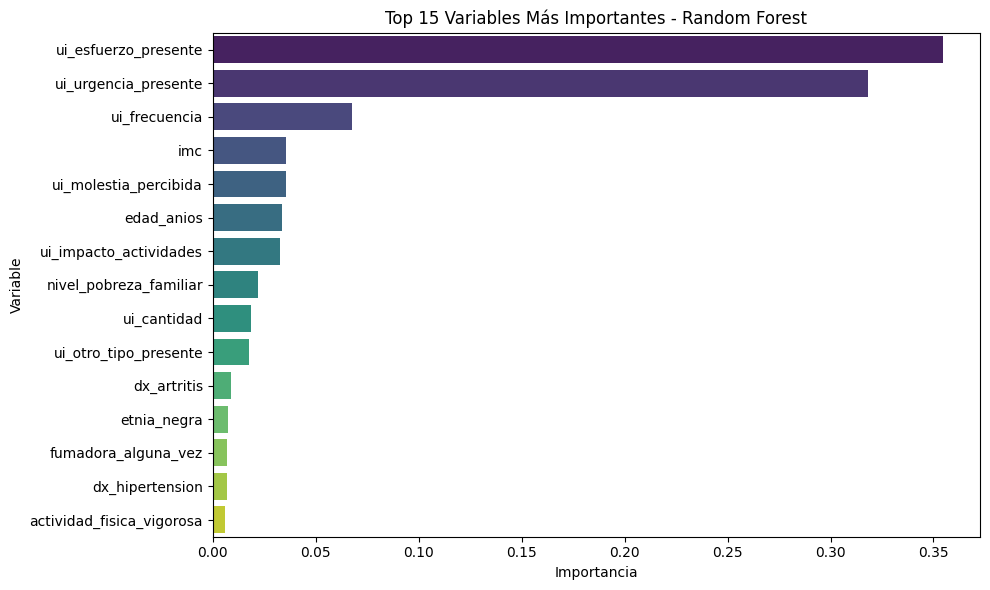

In [6]:
# Obtenemos la importancia de cada columna
importances = rf_tuned.feature_importances_
feature_names = X_train.columns

# Creamos un DataFrame para graficar fácilmente
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Variables Más Importantes - Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

## 6. Métricas Finales

In [7]:
acc = accuracy_score(y_test, y_pred_tuned)
f1m = f1_score(y_test, y_pred_tuned, average='macro')

print("=== MÉTRICAS GLOBALES ===")
print(f"Accuracy:  {acc:.4f}")
print(f"F1-Macro:  {f1m:.4f}")
print("\n=== REPORTE DE CLASIFICACIÓN DETALLADO ===")
print(classification_report(y_test, y_pred_tuned))

=== MÉTRICAS GLOBALES ===
Accuracy:  0.9405
F1-Macro:  0.9365

=== REPORTE DE CLASIFICACIÓN DETALLADO ===
              precision    recall  f1-score   support

       mixed       0.92      1.00      0.96       328
        none       0.99      0.90      0.94       972
      stress       0.89      0.99      0.94       317
        urge       0.87      0.95      0.91       198

    accuracy                           0.94      1815
   macro avg       0.92      0.96      0.94      1815
weighted avg       0.94      0.94      0.94      1815



## 7. Guardar el Modelo Afinado

In [8]:
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "random_forest.pkl")

joblib.dump(rf_tuned, model_path)
print(f"✅ Modelo exportado correctamente en: {model_path}")

✅ Modelo exportado correctamente en: ../models/random_forest.pkl
